# EVT/POT Tail-Risk Analysis

**Topic:** Application of Extreme Value Theory to tail-risk estimation using the Peaks-over-Threshold method.

This notebook is a readable research walkthrough. The reusable implementation is located in `src/evt_pot_analysis.py`, while the report-grade outputs are stored in `results/`.

The common sample covers 29 July 2021–3 March 2026. The three stocks were selected from a ten-stock screening rather than chosen subjectively.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import evt_pot_analysis as evt
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIG_DIR = PROJECT_ROOT / "results" / "figures"


## 1. Data transformation

For closing price $P_t$, logarithmic return and loss are

$$r_t=\ln(P_t/P_{t-1}), \qquad L_t=-r_t.$$

Thus, large positive values of $L_t$ represent severe one-day price declines.

,asset,start_date,end_date,observations,mean_loss,standard_deviation,loss_skewness,excess_kurtosis,q95_loss,q99_loss,maximum_loss
0,NFLX,2021-07-29,2026-03-03,1153,-0.0548%,2.8841%,3.108,50.049,3.612%,6.983%,43.258%
1,META,2021-07-29,2026-03-03,1153,-0.0494%,2.8401%,1.186,25.821,4.077%,6.812%,30.639%
2,INTC,2021-07-29,2026-03-03,1153,0.0104%,3.1067%,0.438,12.505,4.415%,7.690%,30.190%
3,SP500,2021-07-29,2026-03-03,1153,-0.0380%,1.0828%,-0.031,6.581,1.683%,3.019%,6.161%


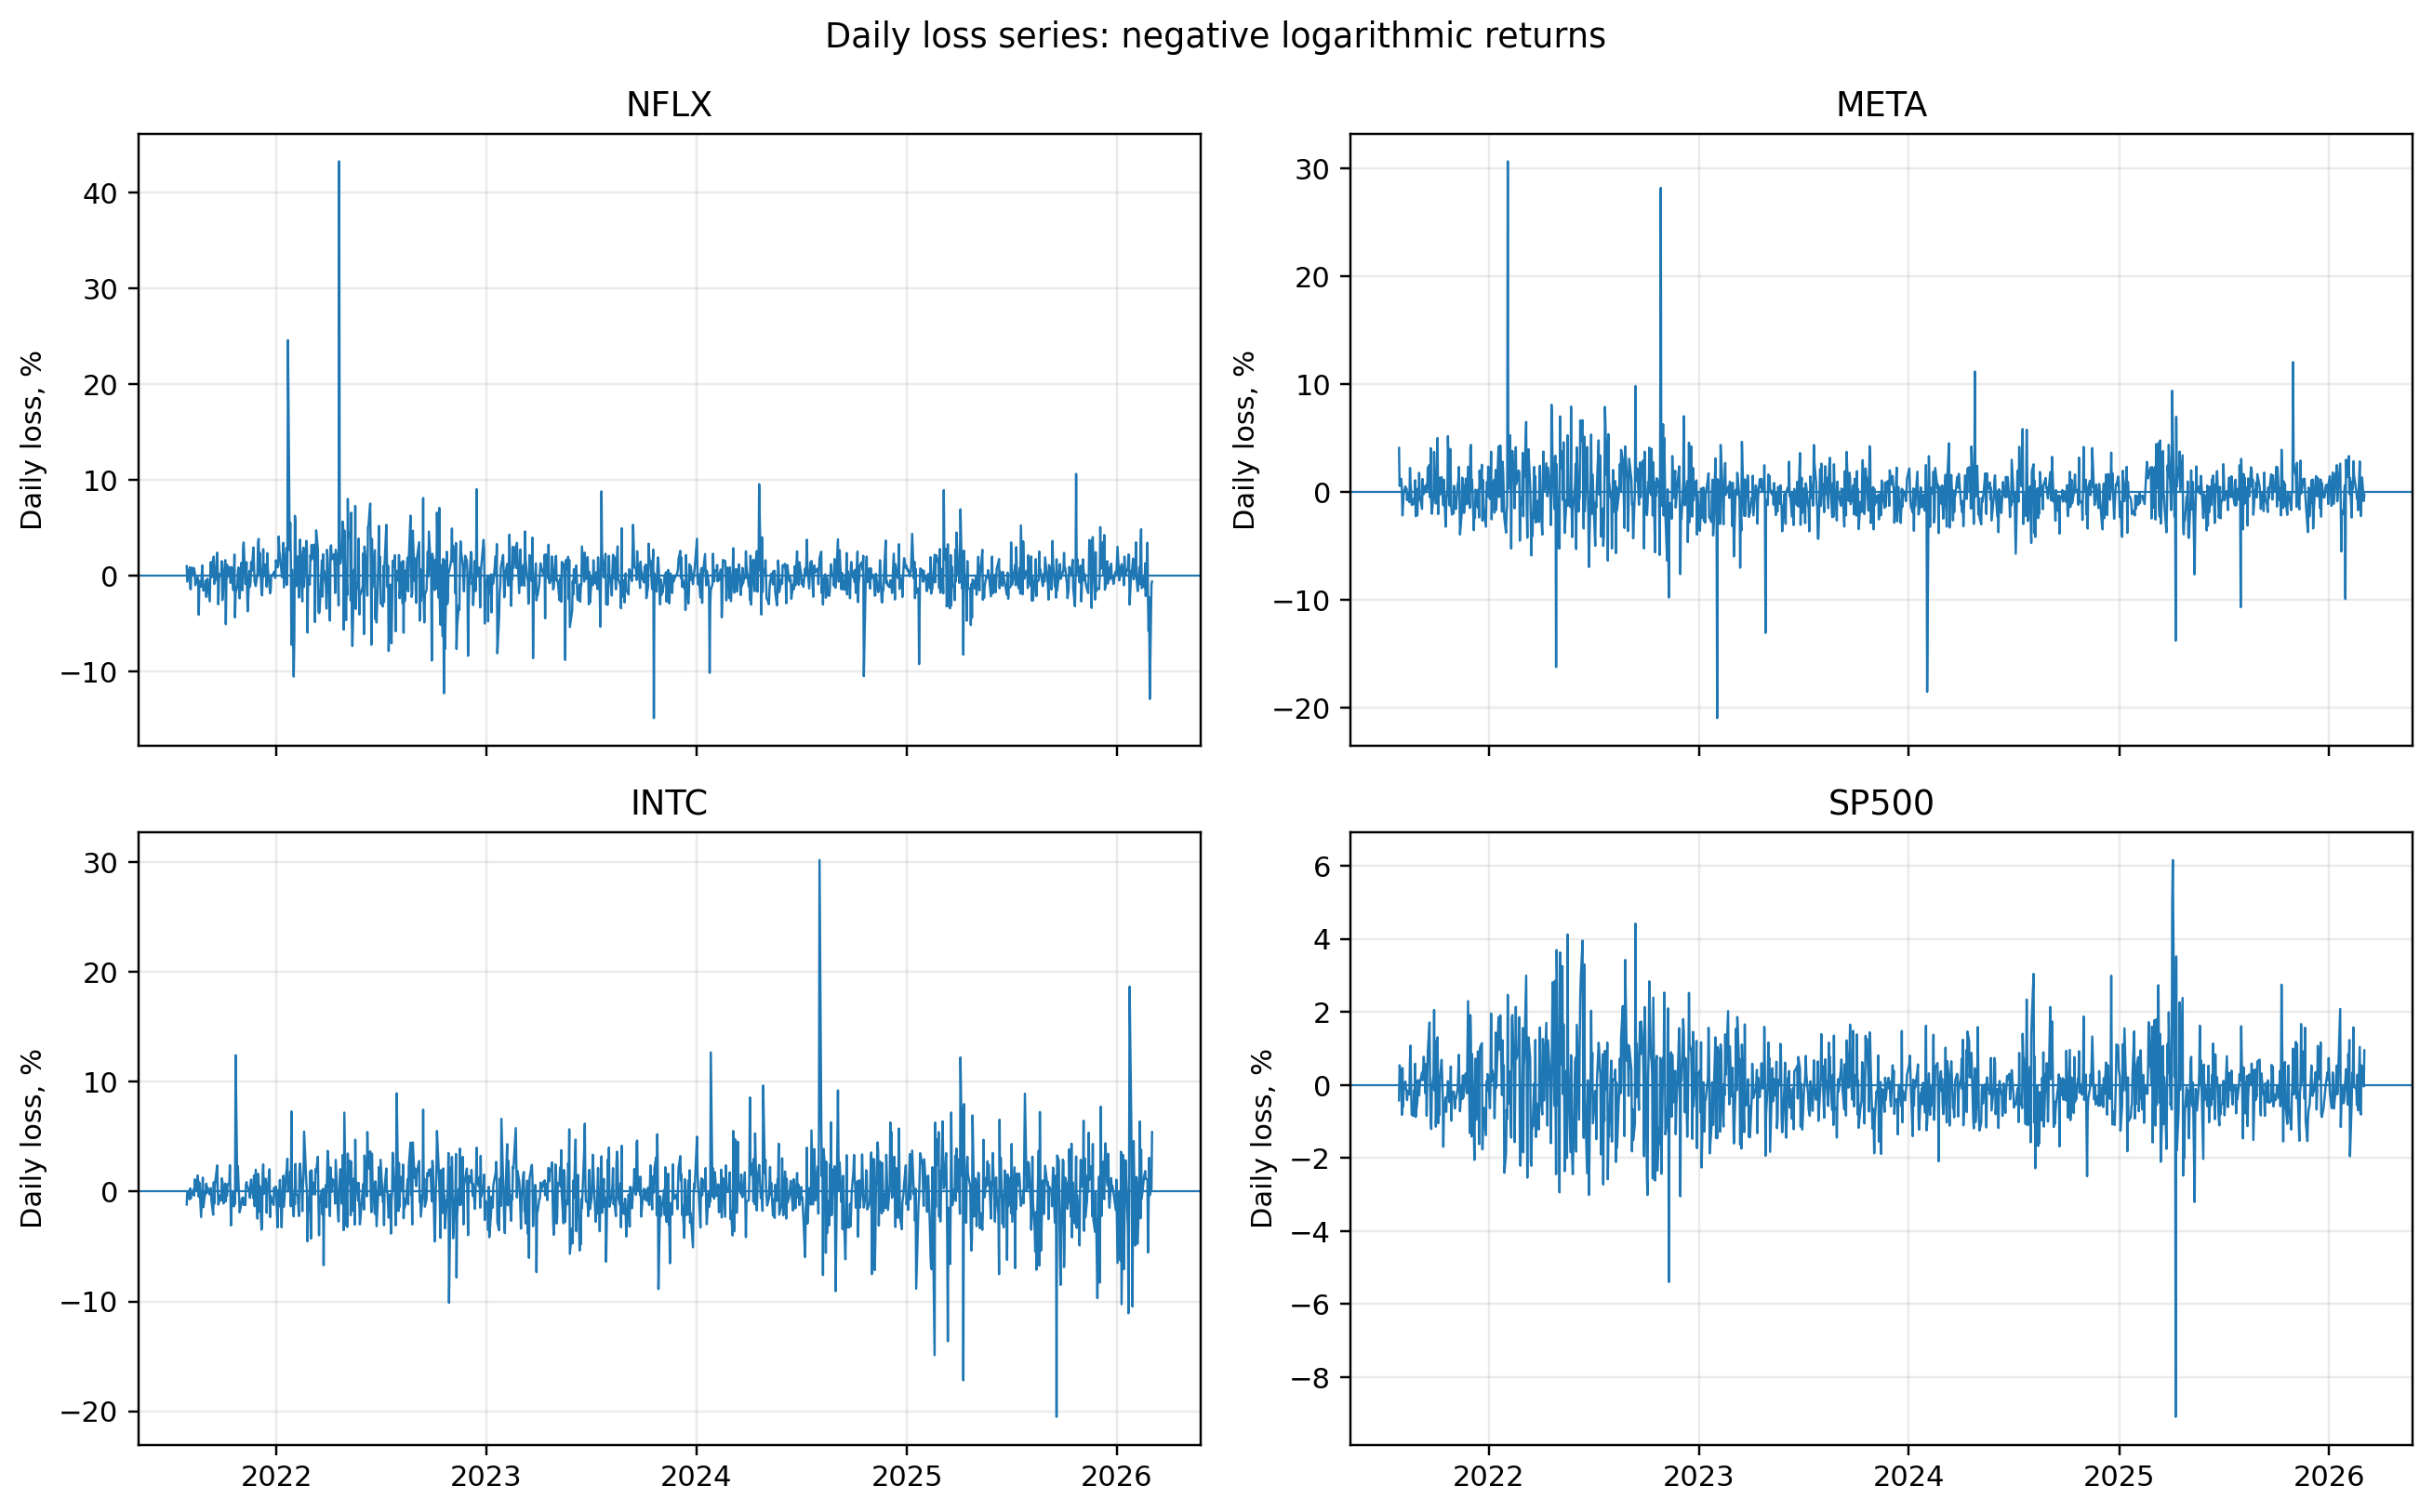

In [2]:
descriptive = pd.read_csv(TABLE_DIR / "descriptive_statistics.csv")
display(descriptive.style.format({
    "mean_loss":"{:.4%}", "standard_deviation":"{:.4%}",
    "q95_loss":"{:.3%}", "q99_loss":"{:.3%}", "maximum_loss":"{:.3%}",
    "loss_skewness":"{:.3f}", "excess_kurtosis":"{:.3f}"
}))
display(Image(filename=str(FIG_DIR / "01_loss_series.png"), width=900))

## 2. Heavy-tail screening

Ten liquid US stocks were ranked using five complementary measures: excess kurtosis, a Hill tail-index estimate, average GPD shape over 90%/92%/95% thresholds, maximum loss, and the 99%-to-95% loss-quantile ratio. Lower average rank means a heavier tail.

,overall_rank,ticker,observations,excess_kurtosis,hill_xi,mean_gpd_xi,maximum_loss,average_tail_rank
0,1,NFLX,1254,51.529,0.395,0.399,43.26%,1.20
1,2,META,1254,26.241,0.411,0.365,30.64%,2.20
2,3,INTC,1254,12.961,0.351,0.264,30.19%,2.80
3,4,AMZN,1254,5.114,0.334,0.151,15.14%,4.60
4,5,AMD,1254,4.166,0.298,0.042,19.01%,6.20
5,6,TSLA,1254,2.770,0.309,0.009,16.75%,6.80
6,7,GOOGL,1254,3.183,0.274,0.105,9.99%,7.40
7,8,MSFT,1254,3.948,0.221,0.110,10.53%,7.60
8,9,AAPL,1254,5.788,0.222,-0.032,9.70%,7.80
9,10,NVDA,1254,3.754,0.179,0.003,18.59%,8.40


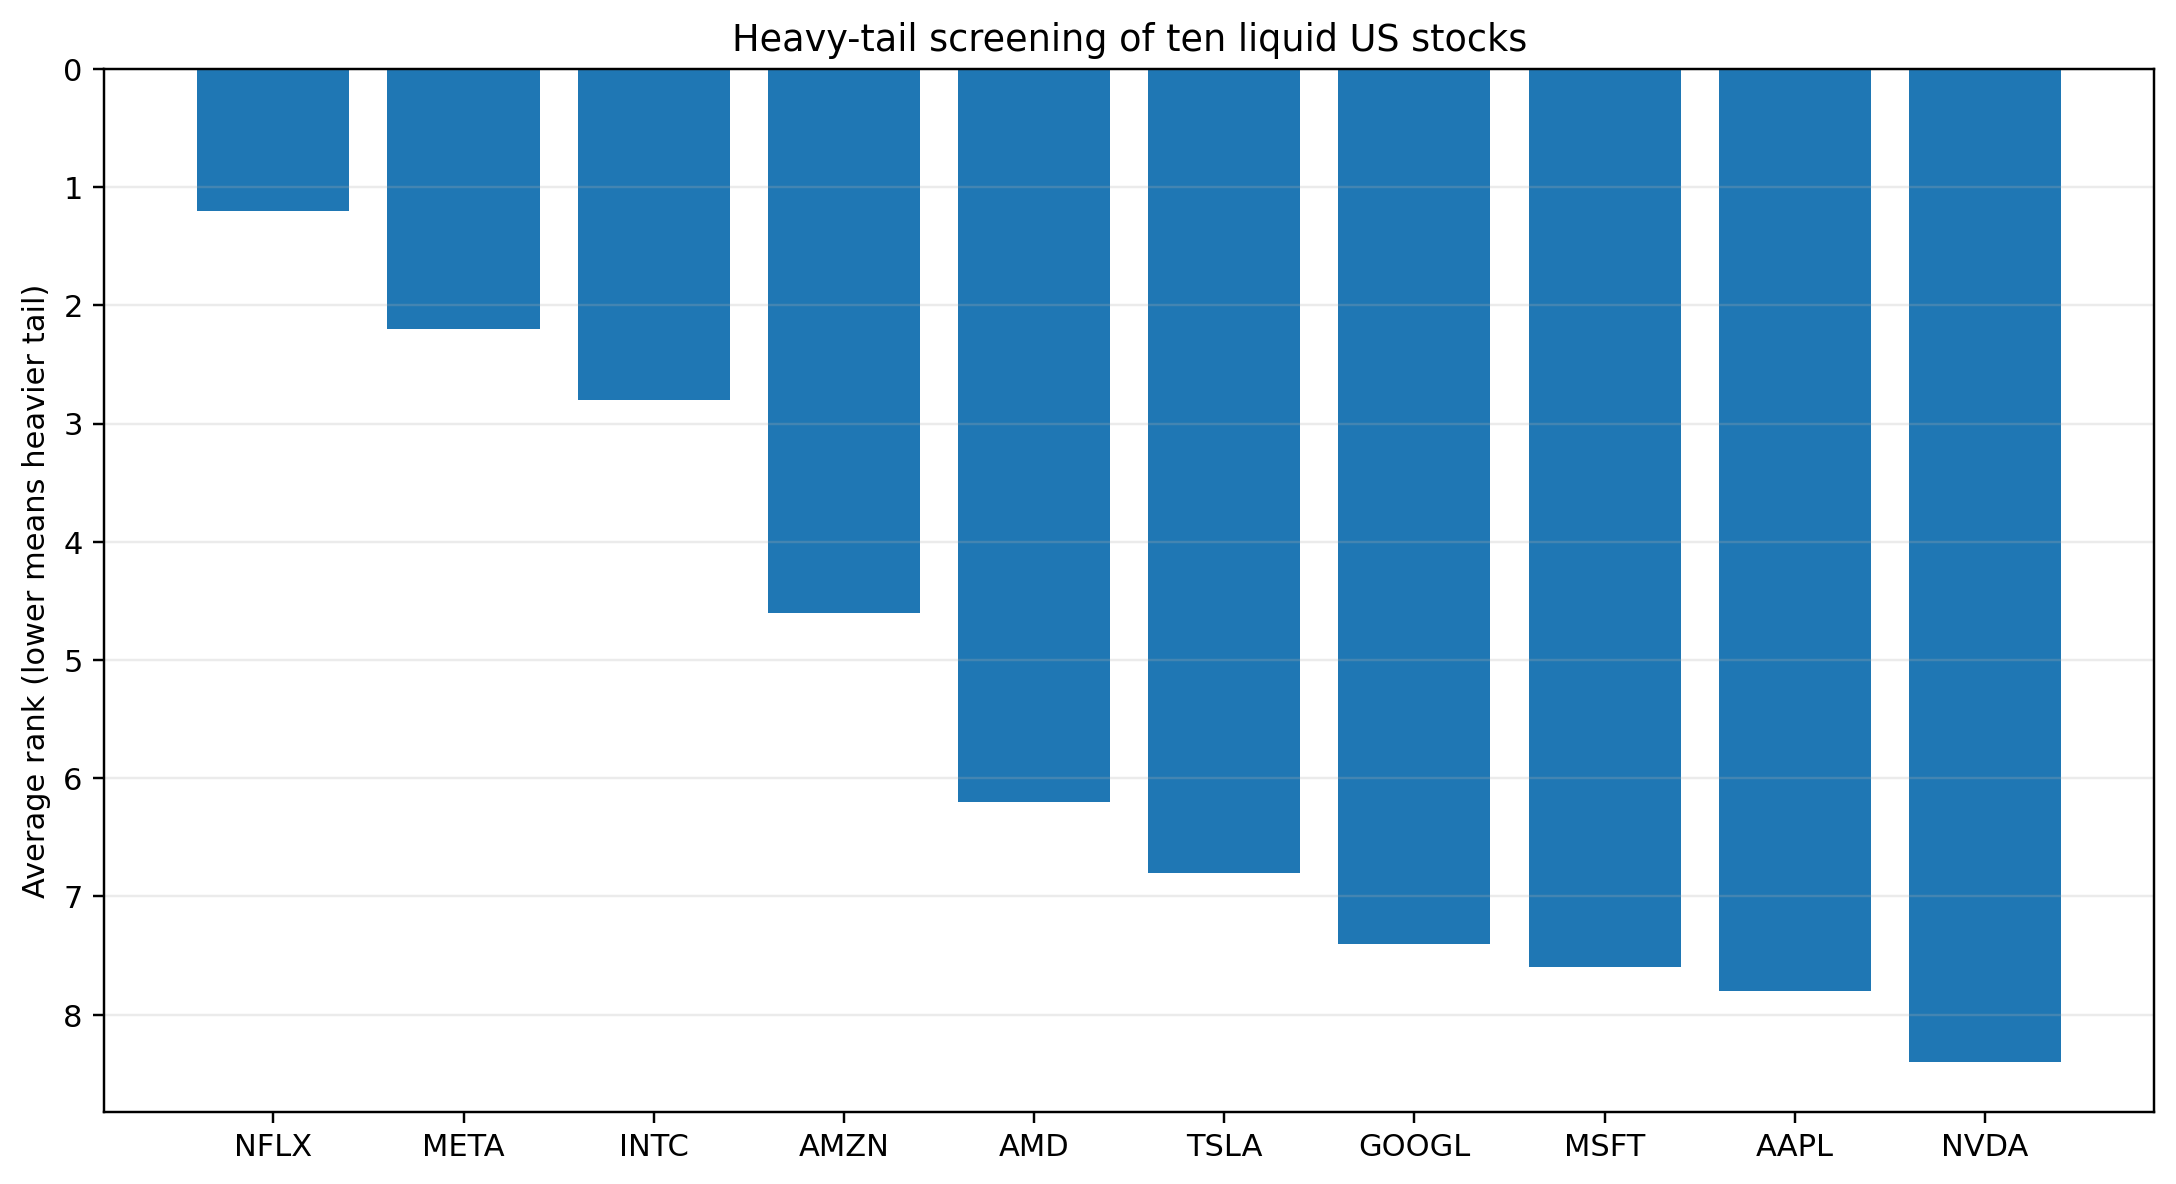

In [3]:
screening = pd.read_csv(TABLE_DIR / "heavy_tail_screening.csv")
cols = ["overall_rank","ticker","observations","excess_kurtosis","hill_xi","mean_gpd_xi","maximum_loss","average_tail_rank"]
display(screening[cols].style.format({
    "excess_kurtosis":"{:.3f}","hill_xi":"{:.3f}","mean_gpd_xi":"{:.3f}",
    "maximum_loss":"{:.2%}","average_tail_rank":"{:.2f}"
}))
display(Image(filename=str(FIG_DIR / "02_heavy_tail_screening.png"), width=850))

## 3. POT threshold selection

For a threshold $u$, the empirical mean excess is

$$\widehat e(u)=\frac{\sum_{i=1}^{n}(L_i-u)\mathbf 1(L_i>u)}{\sum_{i=1}^{n}\mathbf 1(L_i>u)}.$$

A threshold is chosen where the mean excess becomes approximately linear and the fitted shape parameter is reasonably stable, while retaining enough exceedances. The selected thresholds are 92% for NFLX, INTC and S&P 500, and 95% for META.

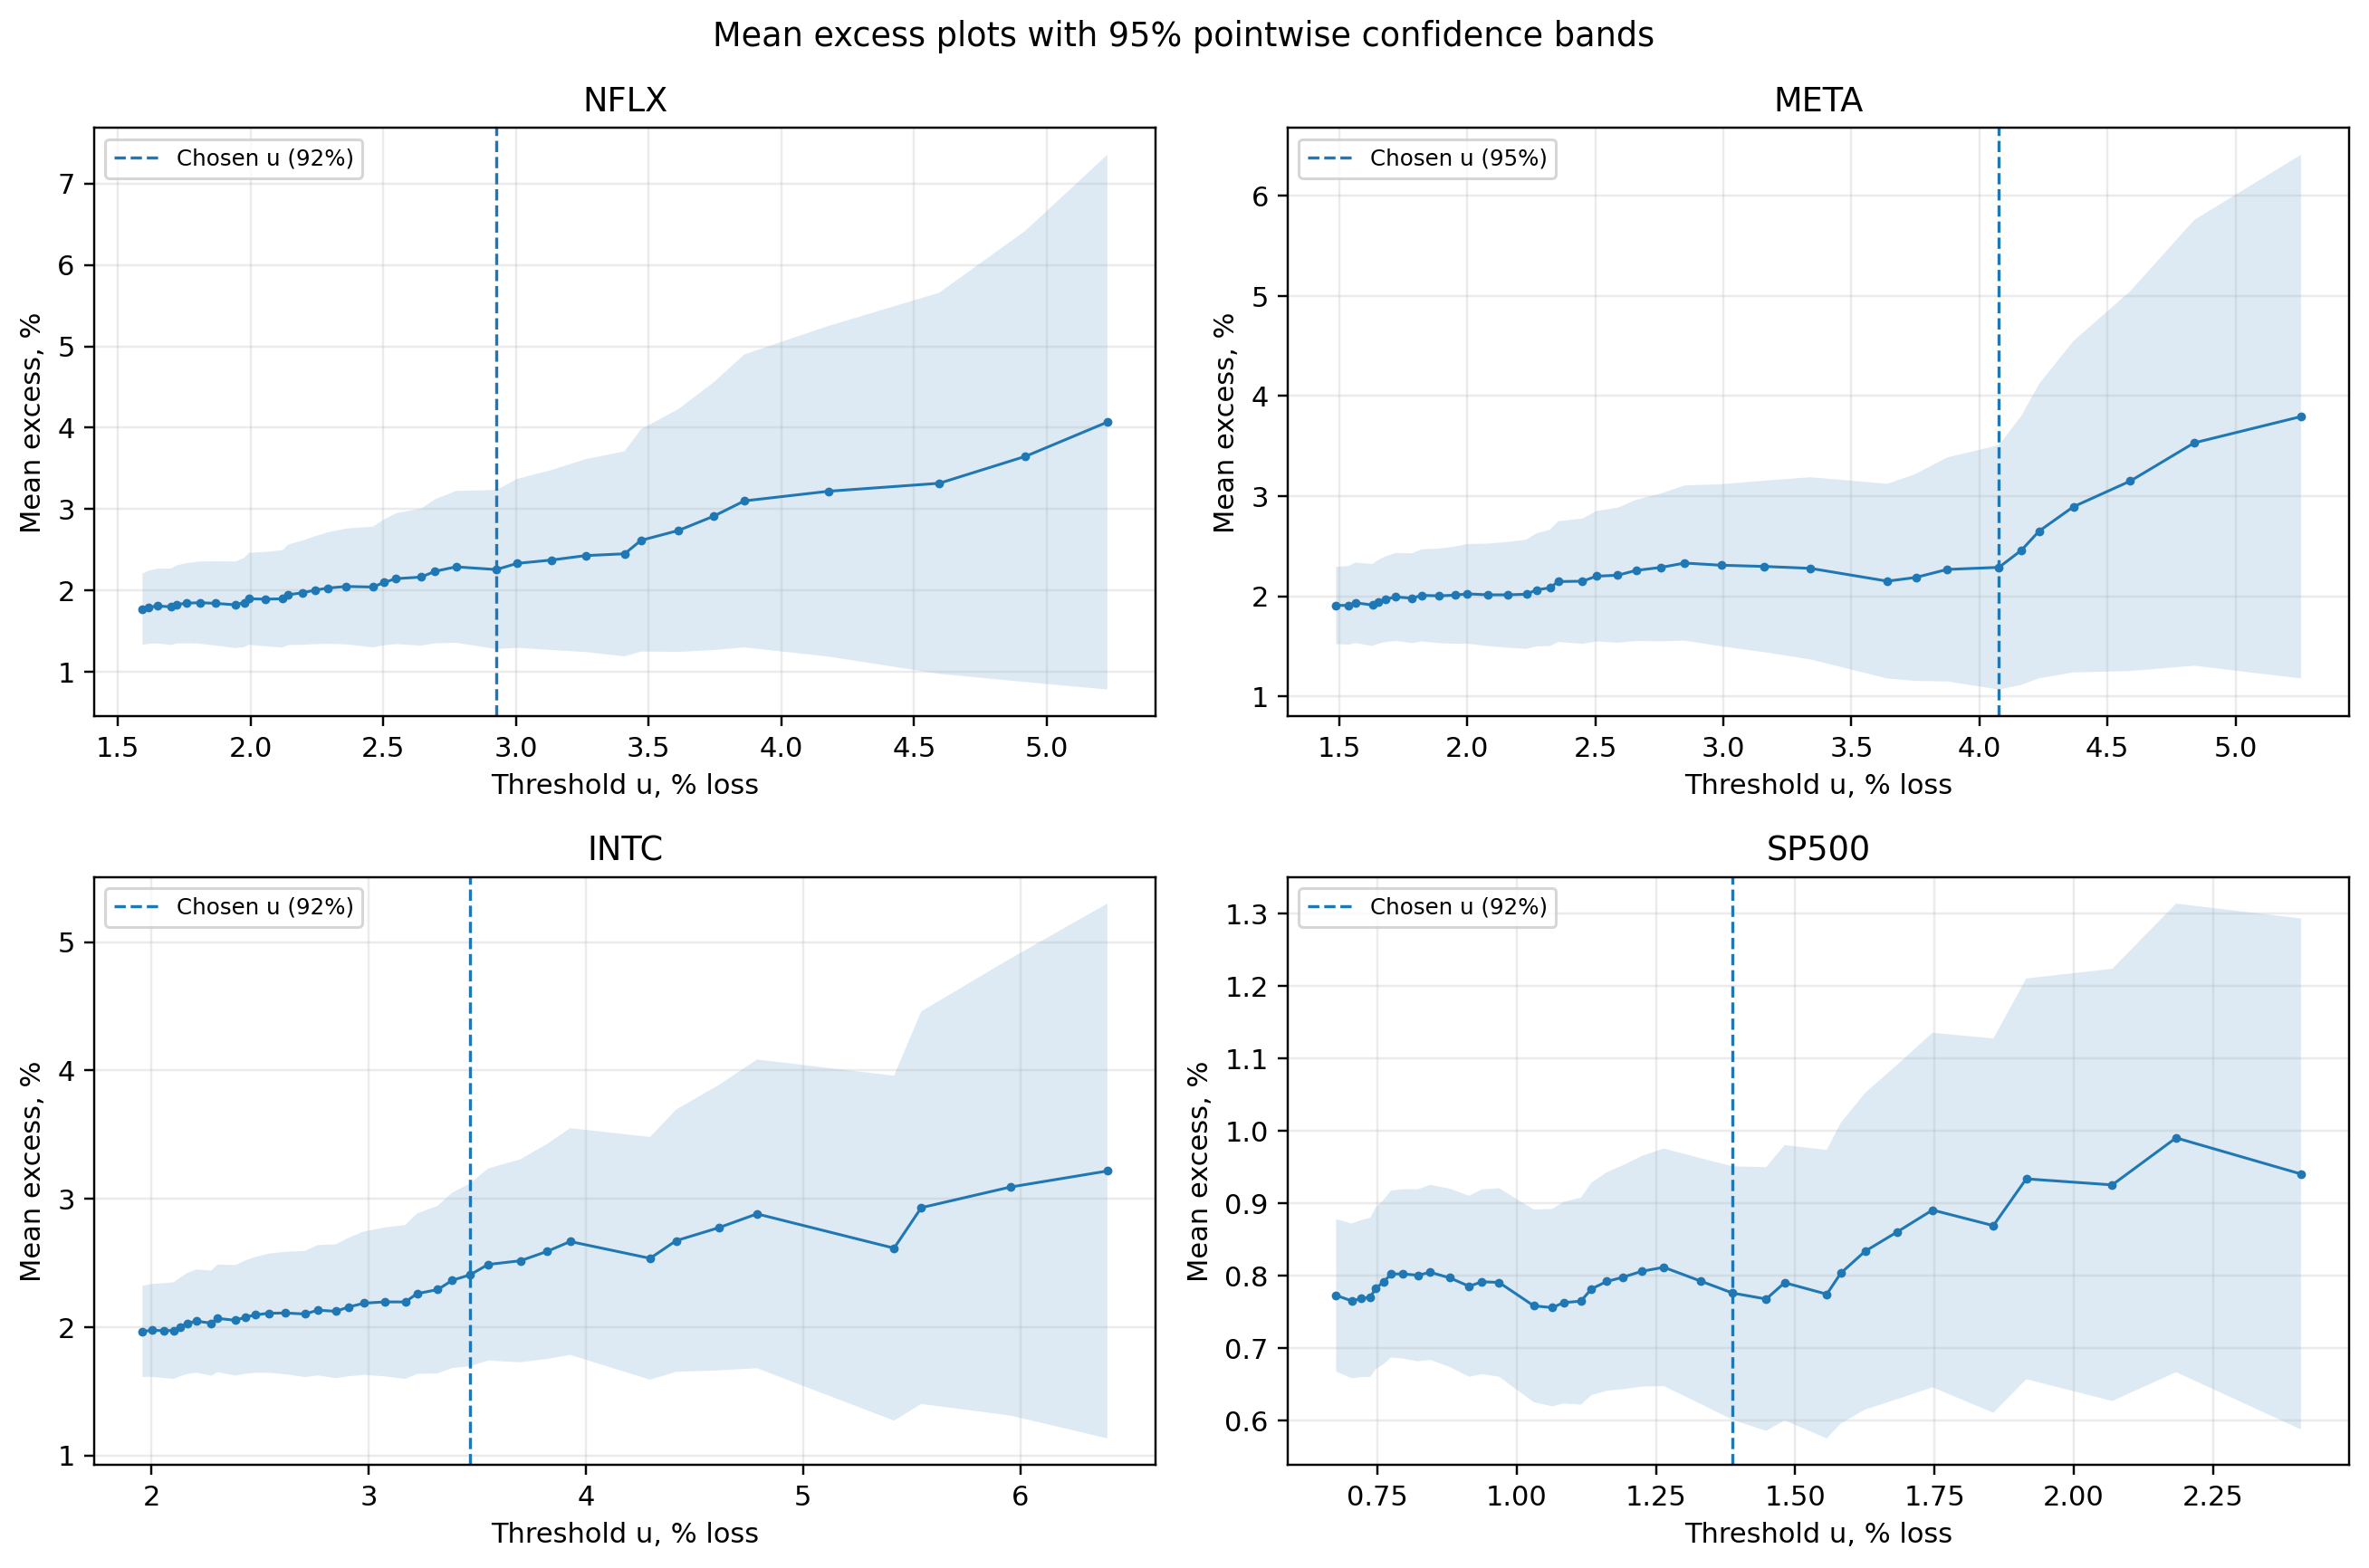

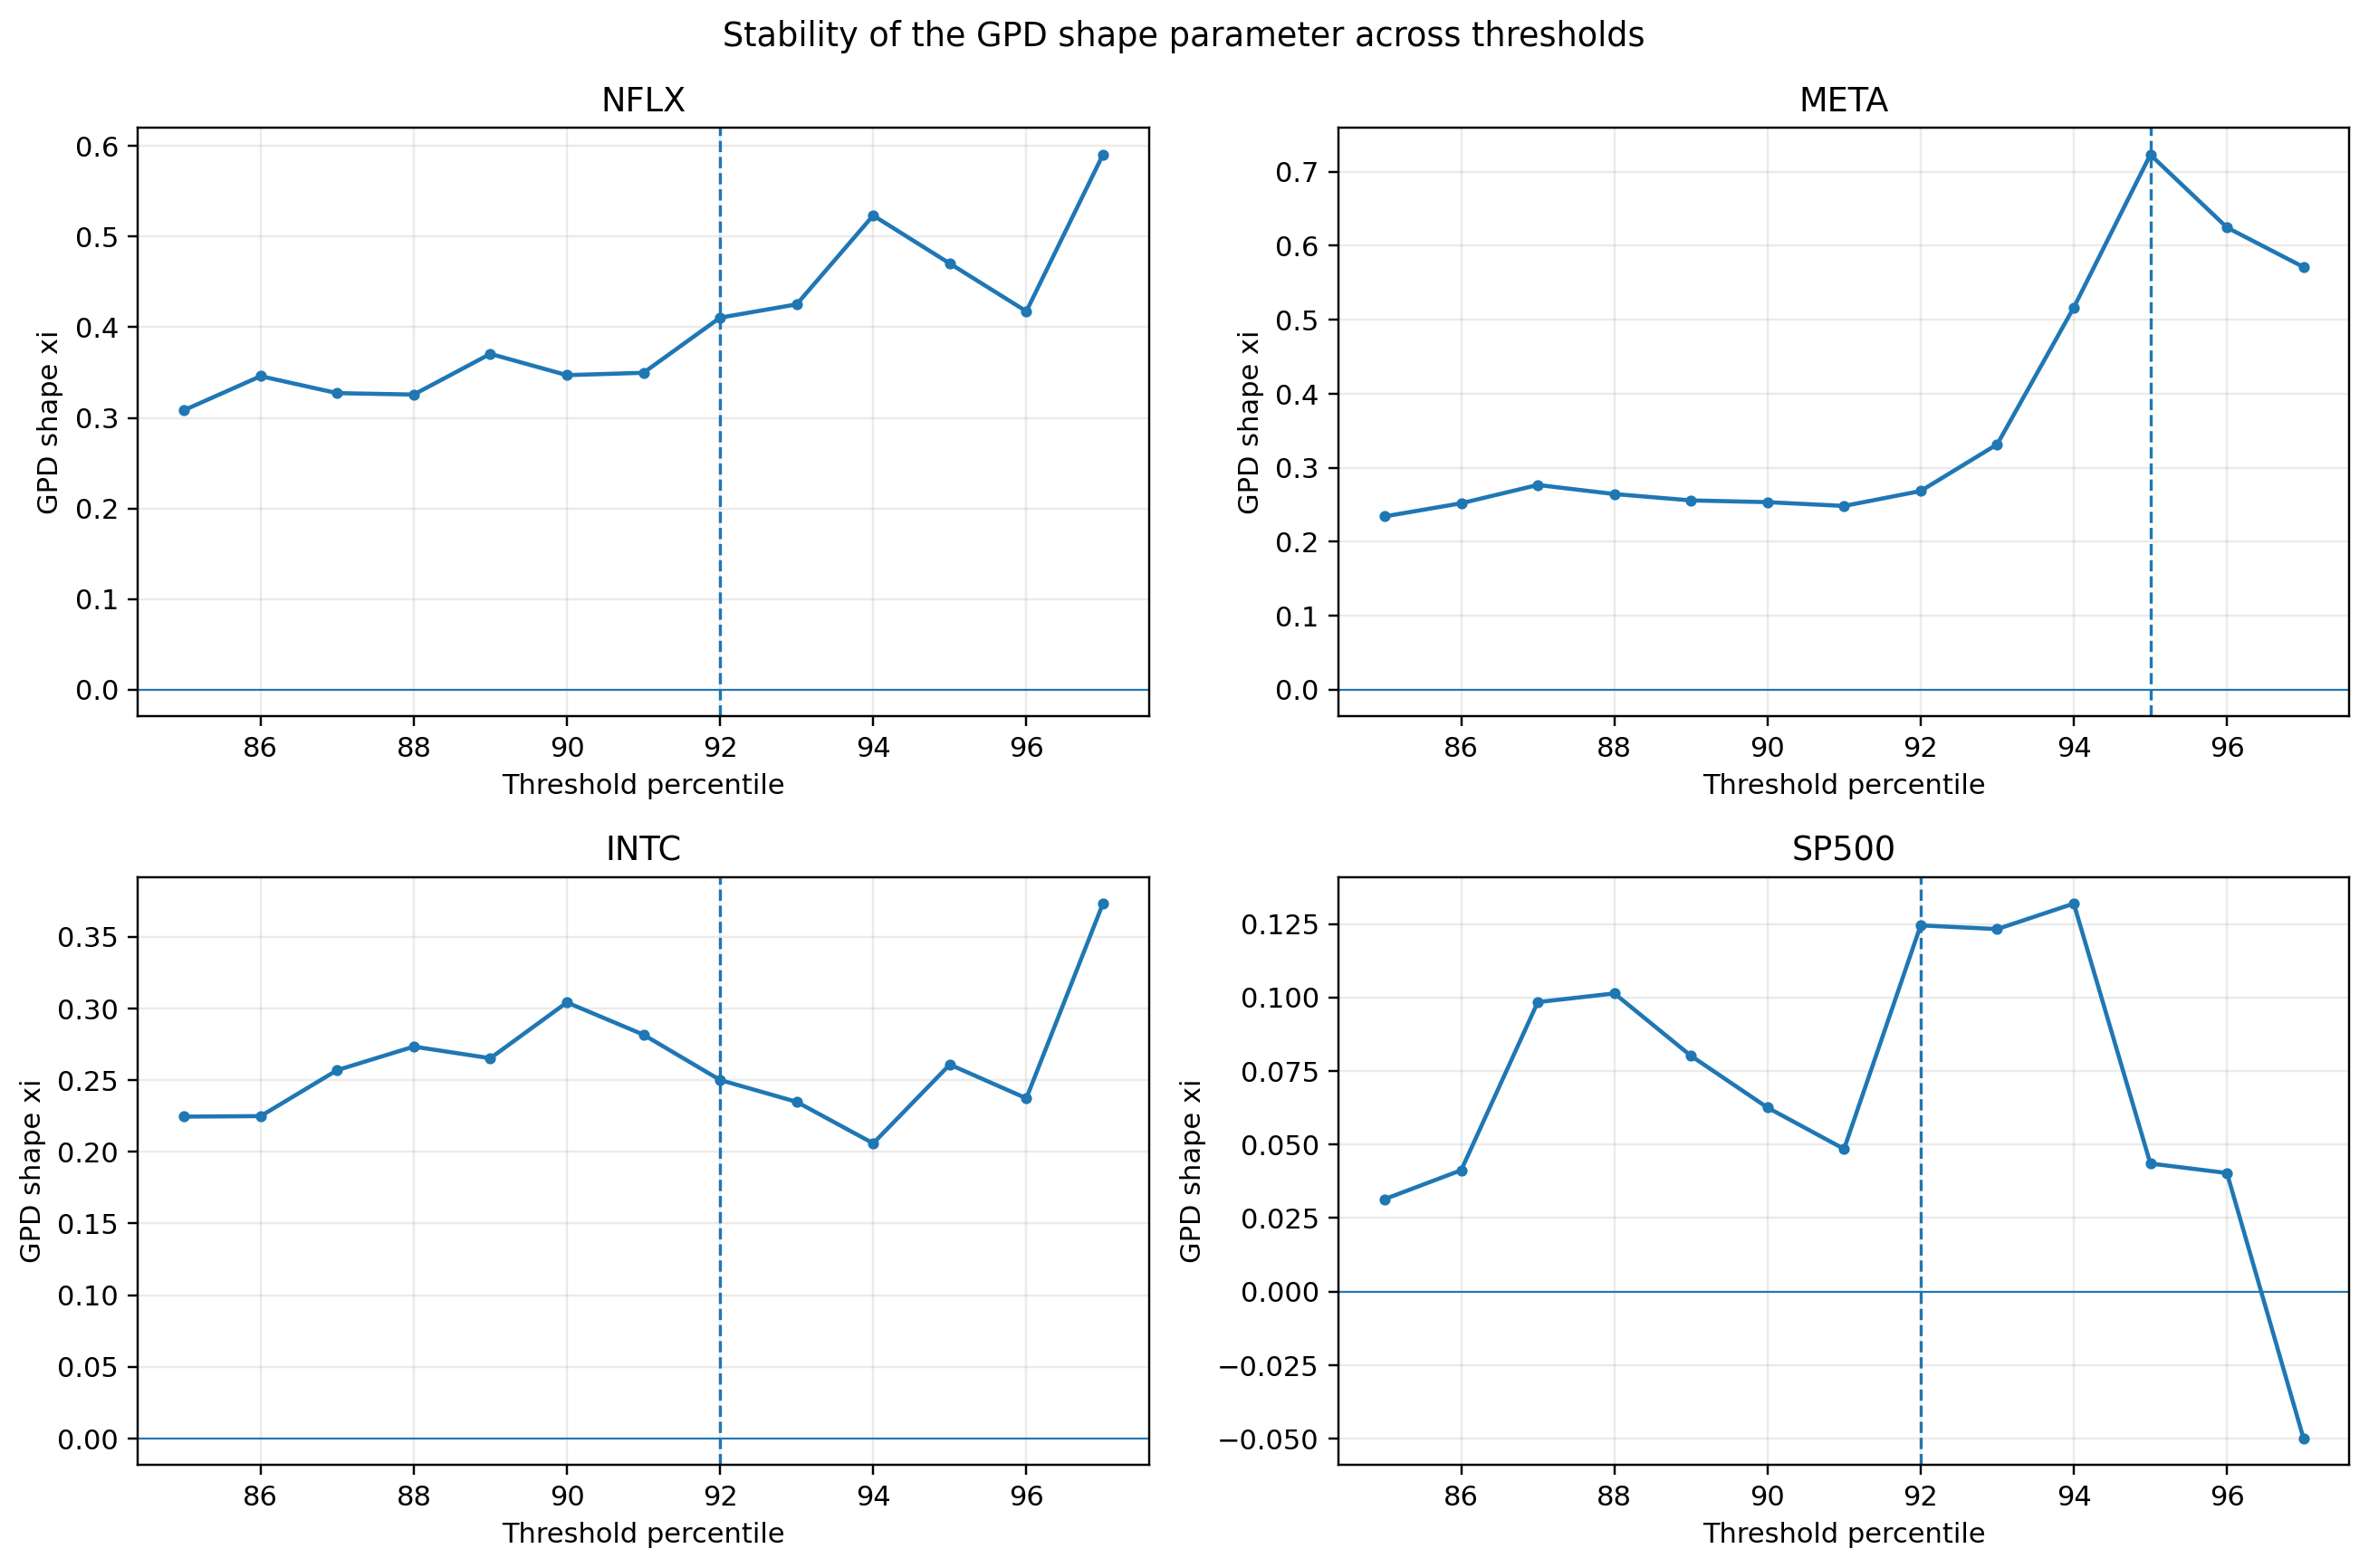

In [4]:
display(Image(filename=str(FIG_DIR / "03_mean_excess_plots.png"), width=950))
display(Image(filename=str(FIG_DIR / "04_shape_parameter_stability.png"), width=950))

## 4. GPD maximum-likelihood fit and goodness of fit

For exceedances $Y=L-u\mid L>u$, the fitted GPD distribution is

$$G_{\xi,\beta}(y)=1-\left(1+\frac{\xi y}{\beta}\right)^{-1/\xi},\quad \beta>0.$$

The Cramer–von Mises test uses a parametric bootstrap with parameter re-estimation in every simulated sample. This adjustment is required because the parameters are estimated from the same exceedances being tested.

,asset,threshold_quantile,threshold,n_exceedances,xi,xi_ci_lower,xi_ci_upper,beta,cvm_statistic,cvm_bootstrap_p
0,NFLX,92%,2.926%,93,0.411,0.082,0.690,0.0128,0.0359,0.766
1,META,95%,4.077%,58,0.723,0.257,1.146,0.0086,0.0368,0.679
2,INTC,92%,3.467%,93,0.250,-0.059,0.494,0.0179,0.0537,0.493
3,SP500,92%,1.388%,93,0.124,-0.127,0.346,0.0068,0.0382,0.768


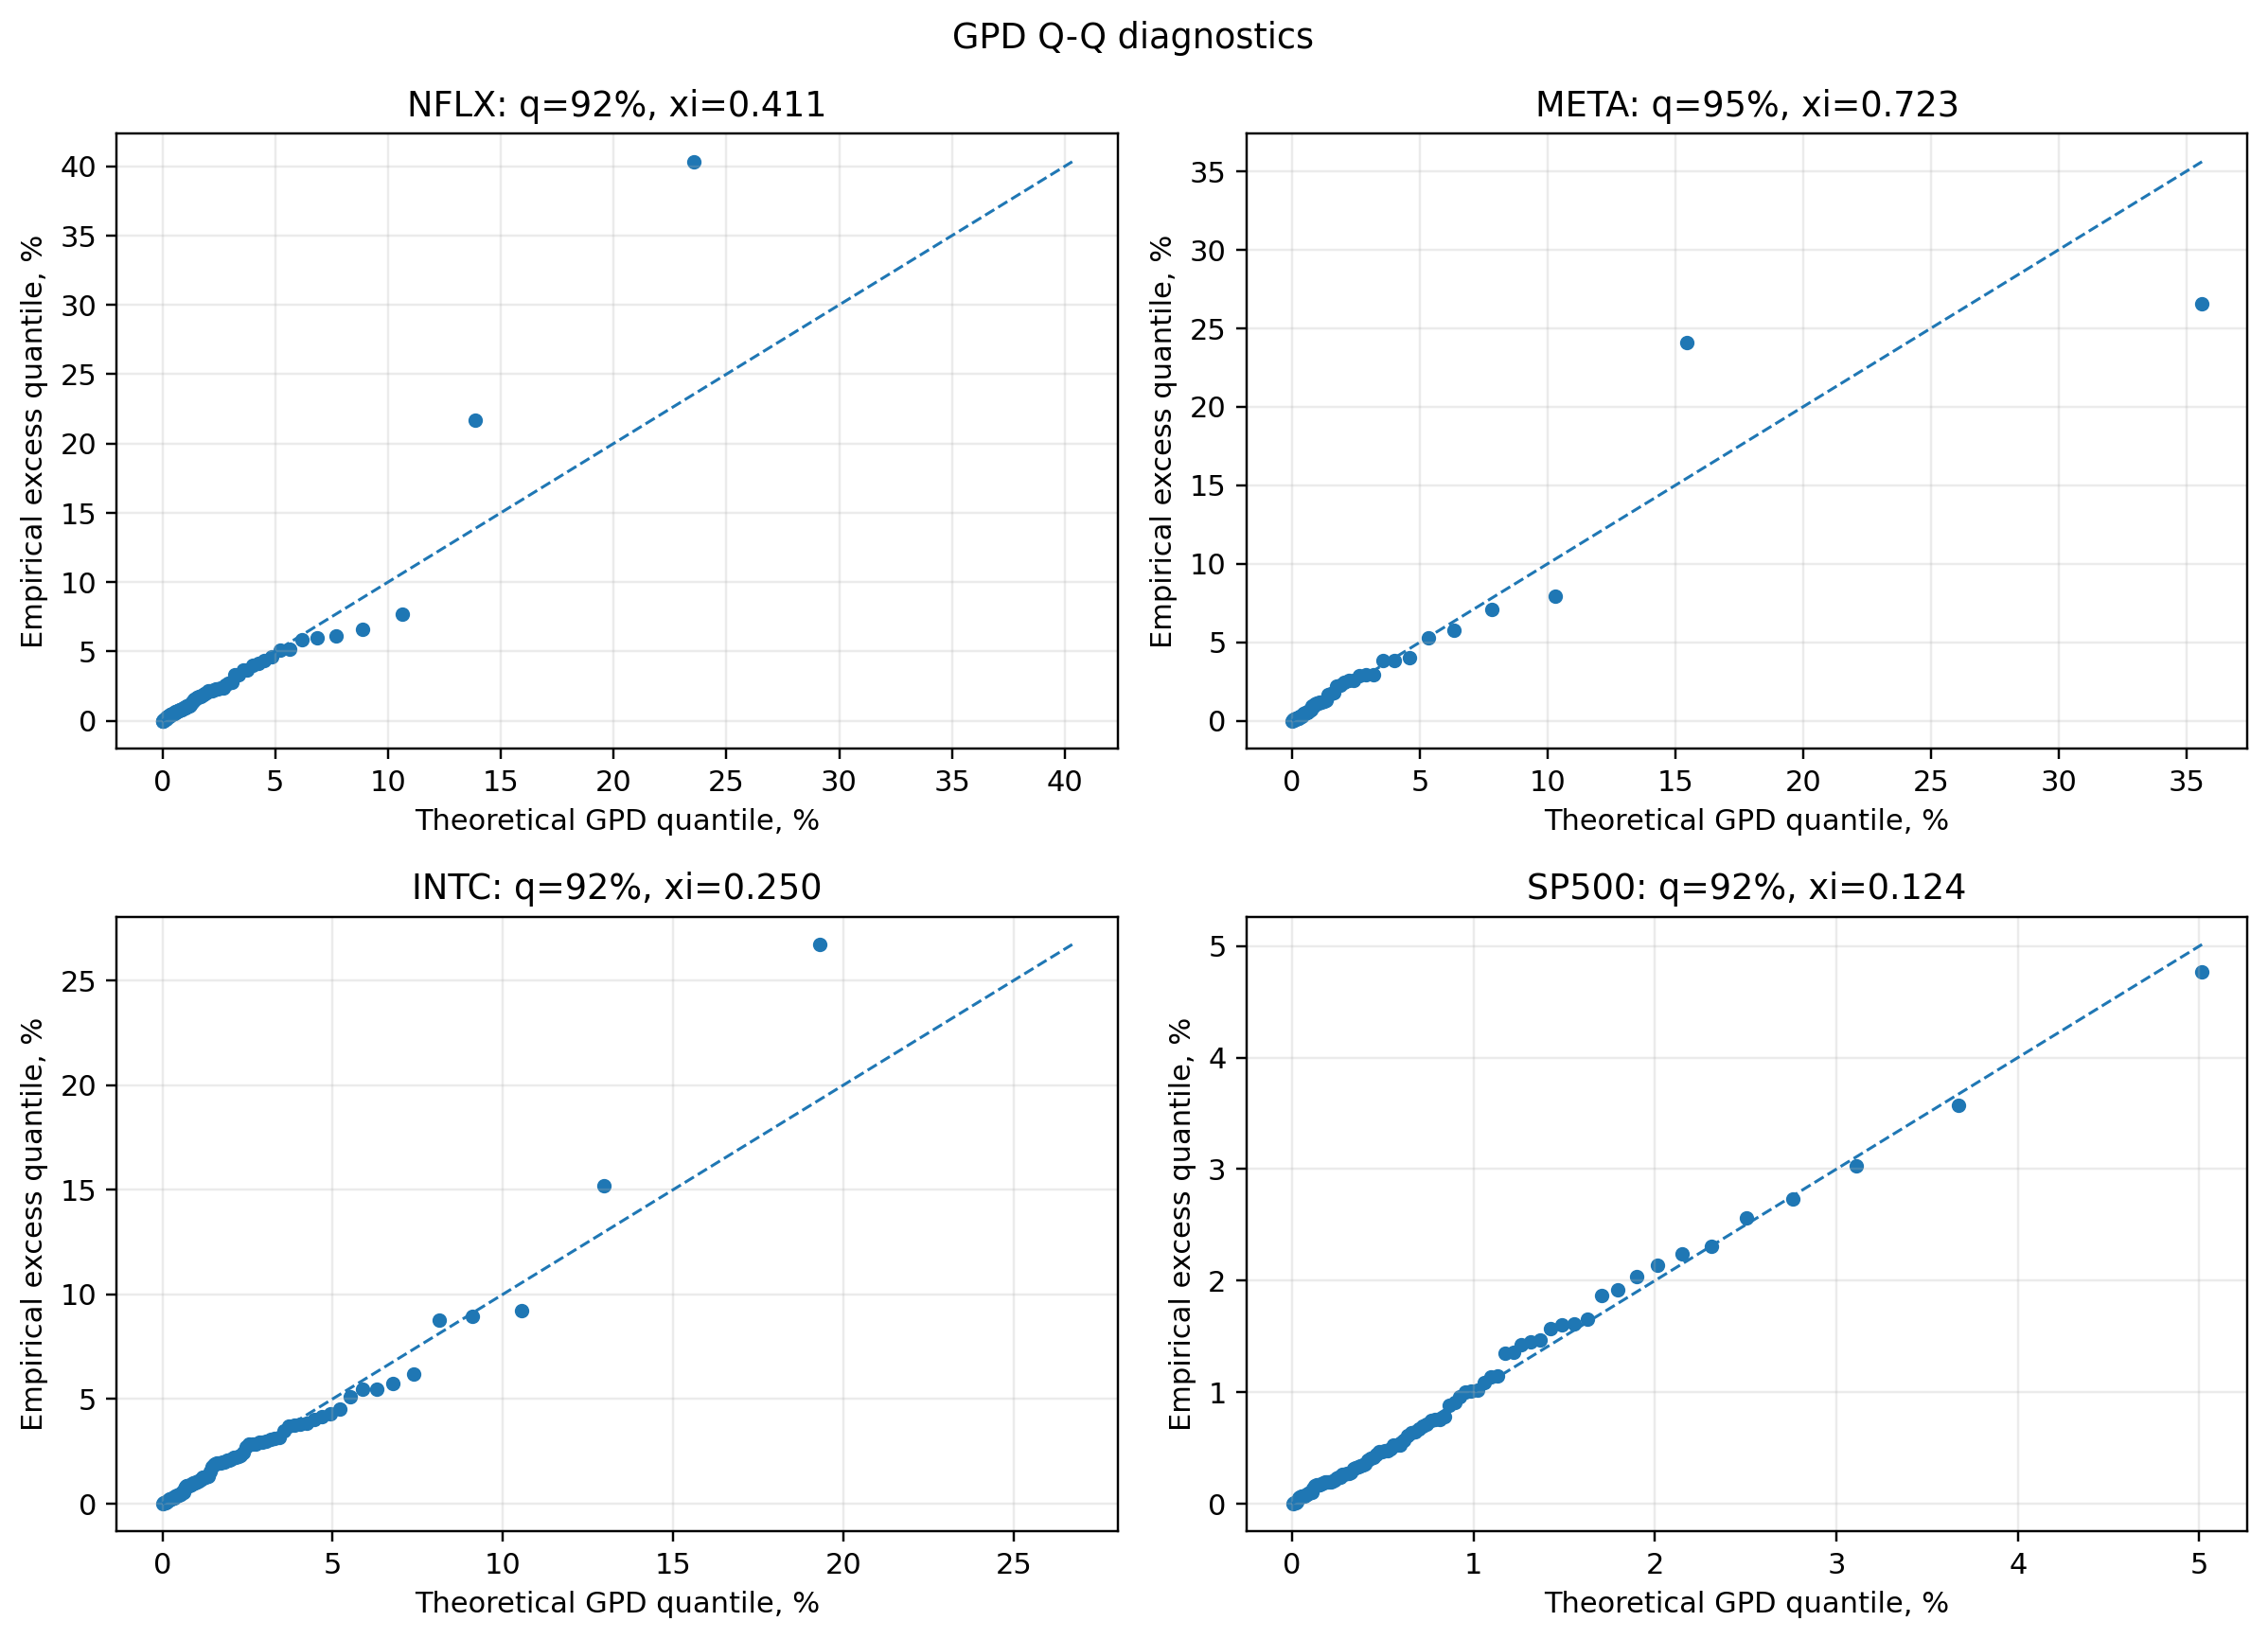

In [5]:
fits = pd.read_csv(TABLE_DIR / "gpd_fit_and_diagnostics.csv")
display(fits[["asset","threshold_quantile","threshold","n_exceedances","xi","xi_ci_lower","xi_ci_upper","beta","cvm_statistic","cvm_bootstrap_p"]].style.format({
    "threshold_quantile":"{:.0%}","threshold":"{:.3%}","xi":"{:.3f}",
    "xi_ci_lower":"{:.3f}","xi_ci_upper":"{:.3f}","beta":"{:.4f}",
    "cvm_statistic":"{:.4f}","cvm_bootstrap_p":"{:.3f}"
}))
display(Image(filename=str(FIG_DIR / "05_gpd_qq_plots.png"), width=900))

## 5. EVT VaR and Expected Shortfall

Let $N_u/n$ be the empirical probability of exceeding the threshold. For $\xi\neq0$,

$$\operatorname{VaR}_q=u+\frac{\beta}{\xi}\left[\left(\frac{N_u}{n(1-q)}\right)^\xi-1\right].$$

For $\xi<1$,

$$\operatorname{ES}_q=\frac{\operatorname{VaR}_q+\beta-\xi u}{1-\xi}.$$

The bootstrap intervals reflect GPD parameter uncertainty. META requires special caution: 8.9% of bootstrap shape estimates are at least one, under which the theoretical ES is infinite.

In [6]:
risk = pd.read_csv(TABLE_DIR / "evt_risk_estimates.csv")
display(risk.style.format({
    "confidence":"{:.1%}","evt_var":"{:.2%}","evt_var_ci_lower":"{:.2%}",
    "evt_var_ci_upper":"{:.2%}","evt_es":"{:.2%}",
    "evt_es_ci_lower_finite":"{:.2%}","evt_es_ci_upper_finite":"{:.2%}",
    "bootstrap_share_undefined_es":"{:.1%}"
}))


,asset,confidence,evt_var,evt_var_ci_lower,evt_var_ci_median,evt_var_ci_upper,evt_es,evt_es_ci_lower_finite,evt_es_ci_median_finite,evt_es_ci_upper_finite,bootstrap_share_undefined_es
0,NFLX,99.0%,7.16%,6.03%,0.070808,8.61%,12.28%,8.33%,0.118428,21.61%,0.0%
1,NFLX,99.5%,9.58%,7.42%,0.094152,12.58%,16.38%,9.84%,0.155821,33.78%,0.0%
2,META,99.0%,6.70%,5.76%,0.066029,8.10%,16.63%,8.04%,0.137668,95.24%,8.9%
3,META,99.5%,9.17%,7.05%,0.088971,13.05%,25.57%,9.82%,0.198770,182.32%,8.9%
4,INTC,99.0%,8.38%,7.26%,0.083085,9.75%,12.41%,9.24%,0.121285,17.82%,0.0%
5,INTC,99.5%,10.67%,8.65%,0.104951,13.23%,15.46%,10.50%,0.149762,24.66%,0.0%
6,SP500,99.0%,3.01%,2.65%,0.029930,3.38%,4.02%,3.26%,0.039654,5.06%,0.0%
7,SP500,99.5%,3.65%,3.08%,0.036135,4.24%,4.75%,3.63%,0.046585,6.34%,0.0%


## 6. Rolling backtesting

A 600-trading-day rolling estimation window produces one-day-ahead forecasts over the last two years of the available common sample. The Kupiec test checks unconditional coverage. The Christoffersen independence and conditional-coverage tests check whether violations occur at the correct rate and without clustering.

,asset,confidence,observations,expected_violations,actual_violations,p_uc,p_ind,p_cc,conditional_coverage_decision_5pct
0,NFLX,99.0%,501,5.01,5,0.996,0.751,0.951,Do not reject
1,NFLX,99.5%,501,2.51,3,0.761,0.849,0.938,Do not reject
2,META,99.0%,501,5.01,4,0.638,0.799,0.867,Do not reject
3,META,99.5%,501,2.51,4,0.384,0.799,0.663,Do not reject
4,INTC,99.0%,501,5.01,7,0.399,0.656,0.635,Do not reject
5,INTC,99.5%,501,2.51,5,0.164,0.751,0.361,Do not reject
6,SP500,99.0%,501,5.01,6,0.666,0.054,0.142,Do not reject
7,SP500,99.5%,501,2.51,5,0.164,0.034,0.040,Reject


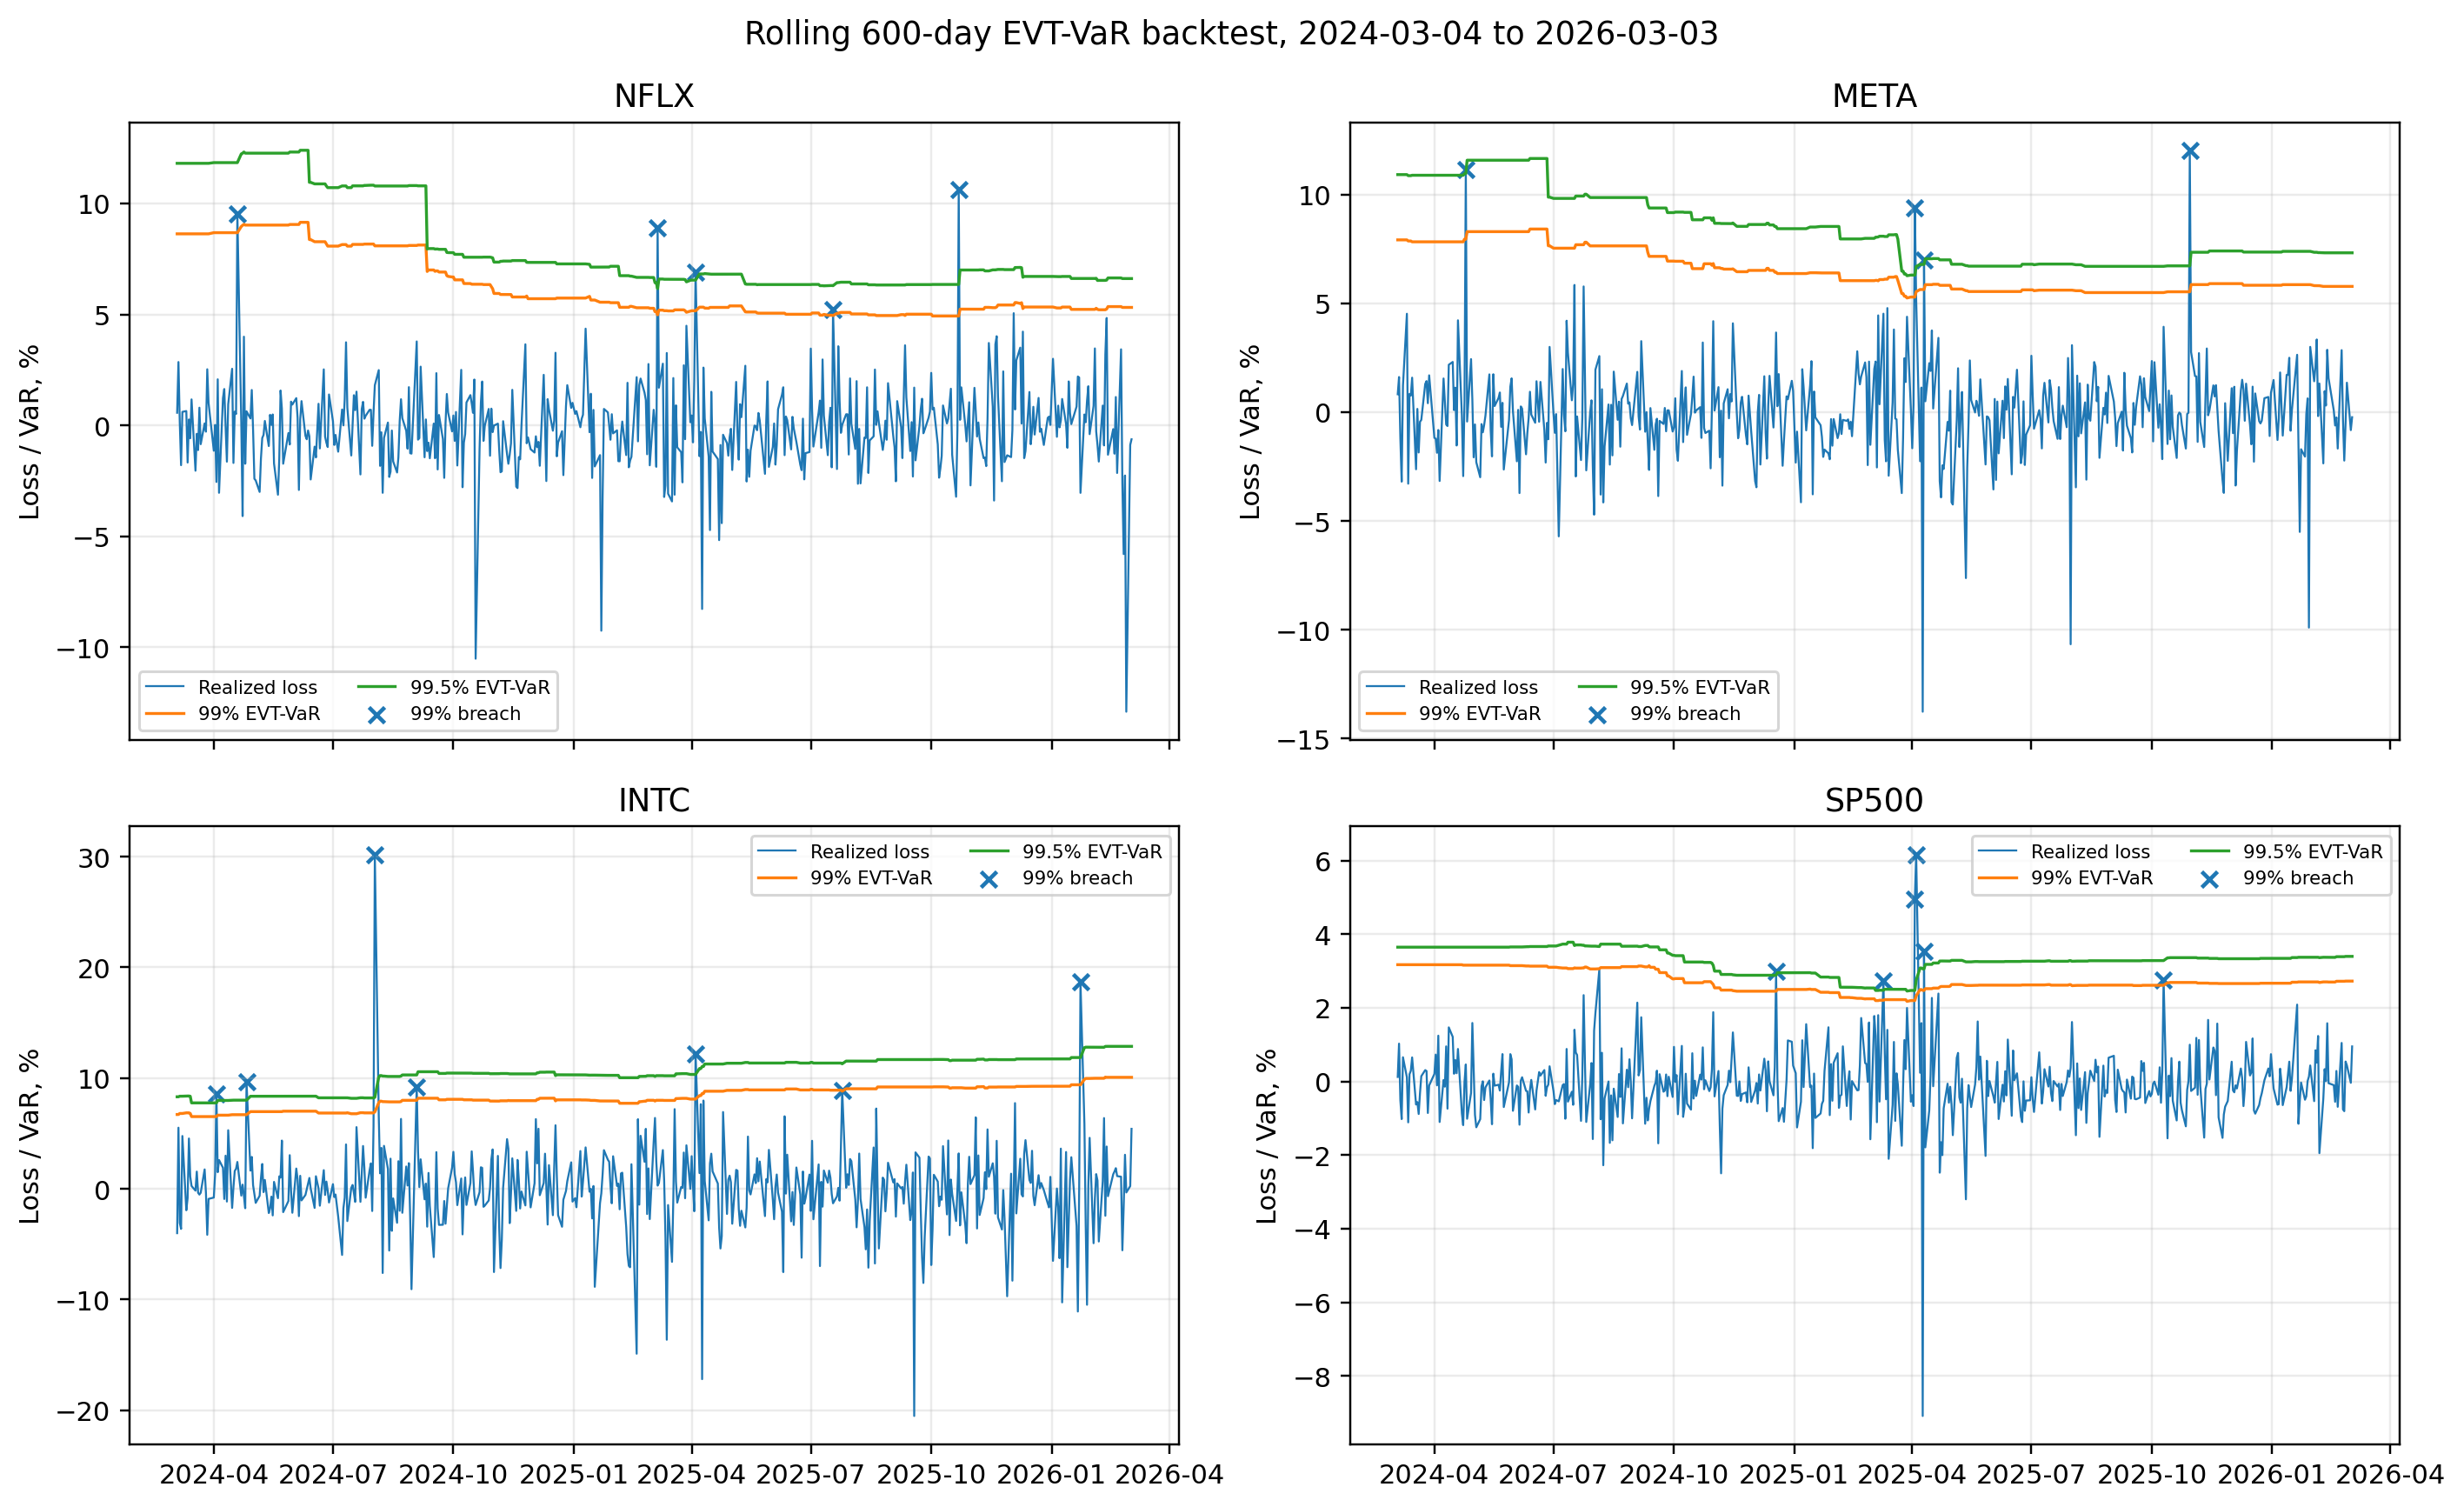

In [7]:
backtests = pd.read_csv(TABLE_DIR / "backtest_tests.csv")
cols = ["asset","confidence","observations","expected_violations","actual_violations","p_uc","p_ind","p_cc","conditional_coverage_decision_5pct"]
display(backtests[cols].style.format({
    "confidence":"{:.1%}","expected_violations":"{:.2f}",
    "p_uc":"{:.3f}","p_ind":"{:.3f}","p_cc":"{:.3f}"
}))
display(Image(filename=str(FIG_DIR / "08_evt_var_backtests.png"), width=1000))

## 7. Sensitivity to threshold choice

The requested 90%, 92% and 95% thresholds are compared. VaR is stable for NFLX, INTC and S&P 500. META is different: the 90% and 92% GPD fits have bootstrap Cramer–von Mises p-values near 0.002, so the apparently stable lower-threshold VaR estimates are not accepted as valid tail models.

,asset,threshold_quantile,threshold,n_exceedances,xi,beta,cvm_bootstrap_p,confidence,evt_var,evt_es,selected_threshold
0,NFLX,90%,2.55%,116,0.347,0.0134,0.513,99.0%,7.28%,11.85%,False
1,NFLX,90%,2.55%,116,0.347,0.0134,0.513,99.5%,9.62%,15.43%,False
2,NFLX,92%,2.93%,93,0.411,0.0128,0.766,99.0%,7.16%,12.28%,True
3,NFLX,92%,2.93%,93,0.411,0.0128,0.766,99.5%,9.58%,16.38%,True
4,NFLX,95%,3.61%,58,0.470,0.0142,0.579,99.0%,7.05%,12.78%,False
5,NFLX,95%,3.61%,58,0.470,0.0142,0.579,99.5%,9.54%,17.48%,False
6,META,90%,2.59%,116,0.253,0.0160,0.002,99.0%,7.61%,11.46%,False
7,META,90%,2.59%,116,0.253,0.0160,0.002,99.5%,9.79%,14.38%,False
8,META,92%,2.99%,93,0.268,0.0163,0.002,99.0%,7.55%,11.46%,False
9,META,92%,2.99%,93,0.268,0.0163,0.002,99.5%,9.73%,14.43%,False


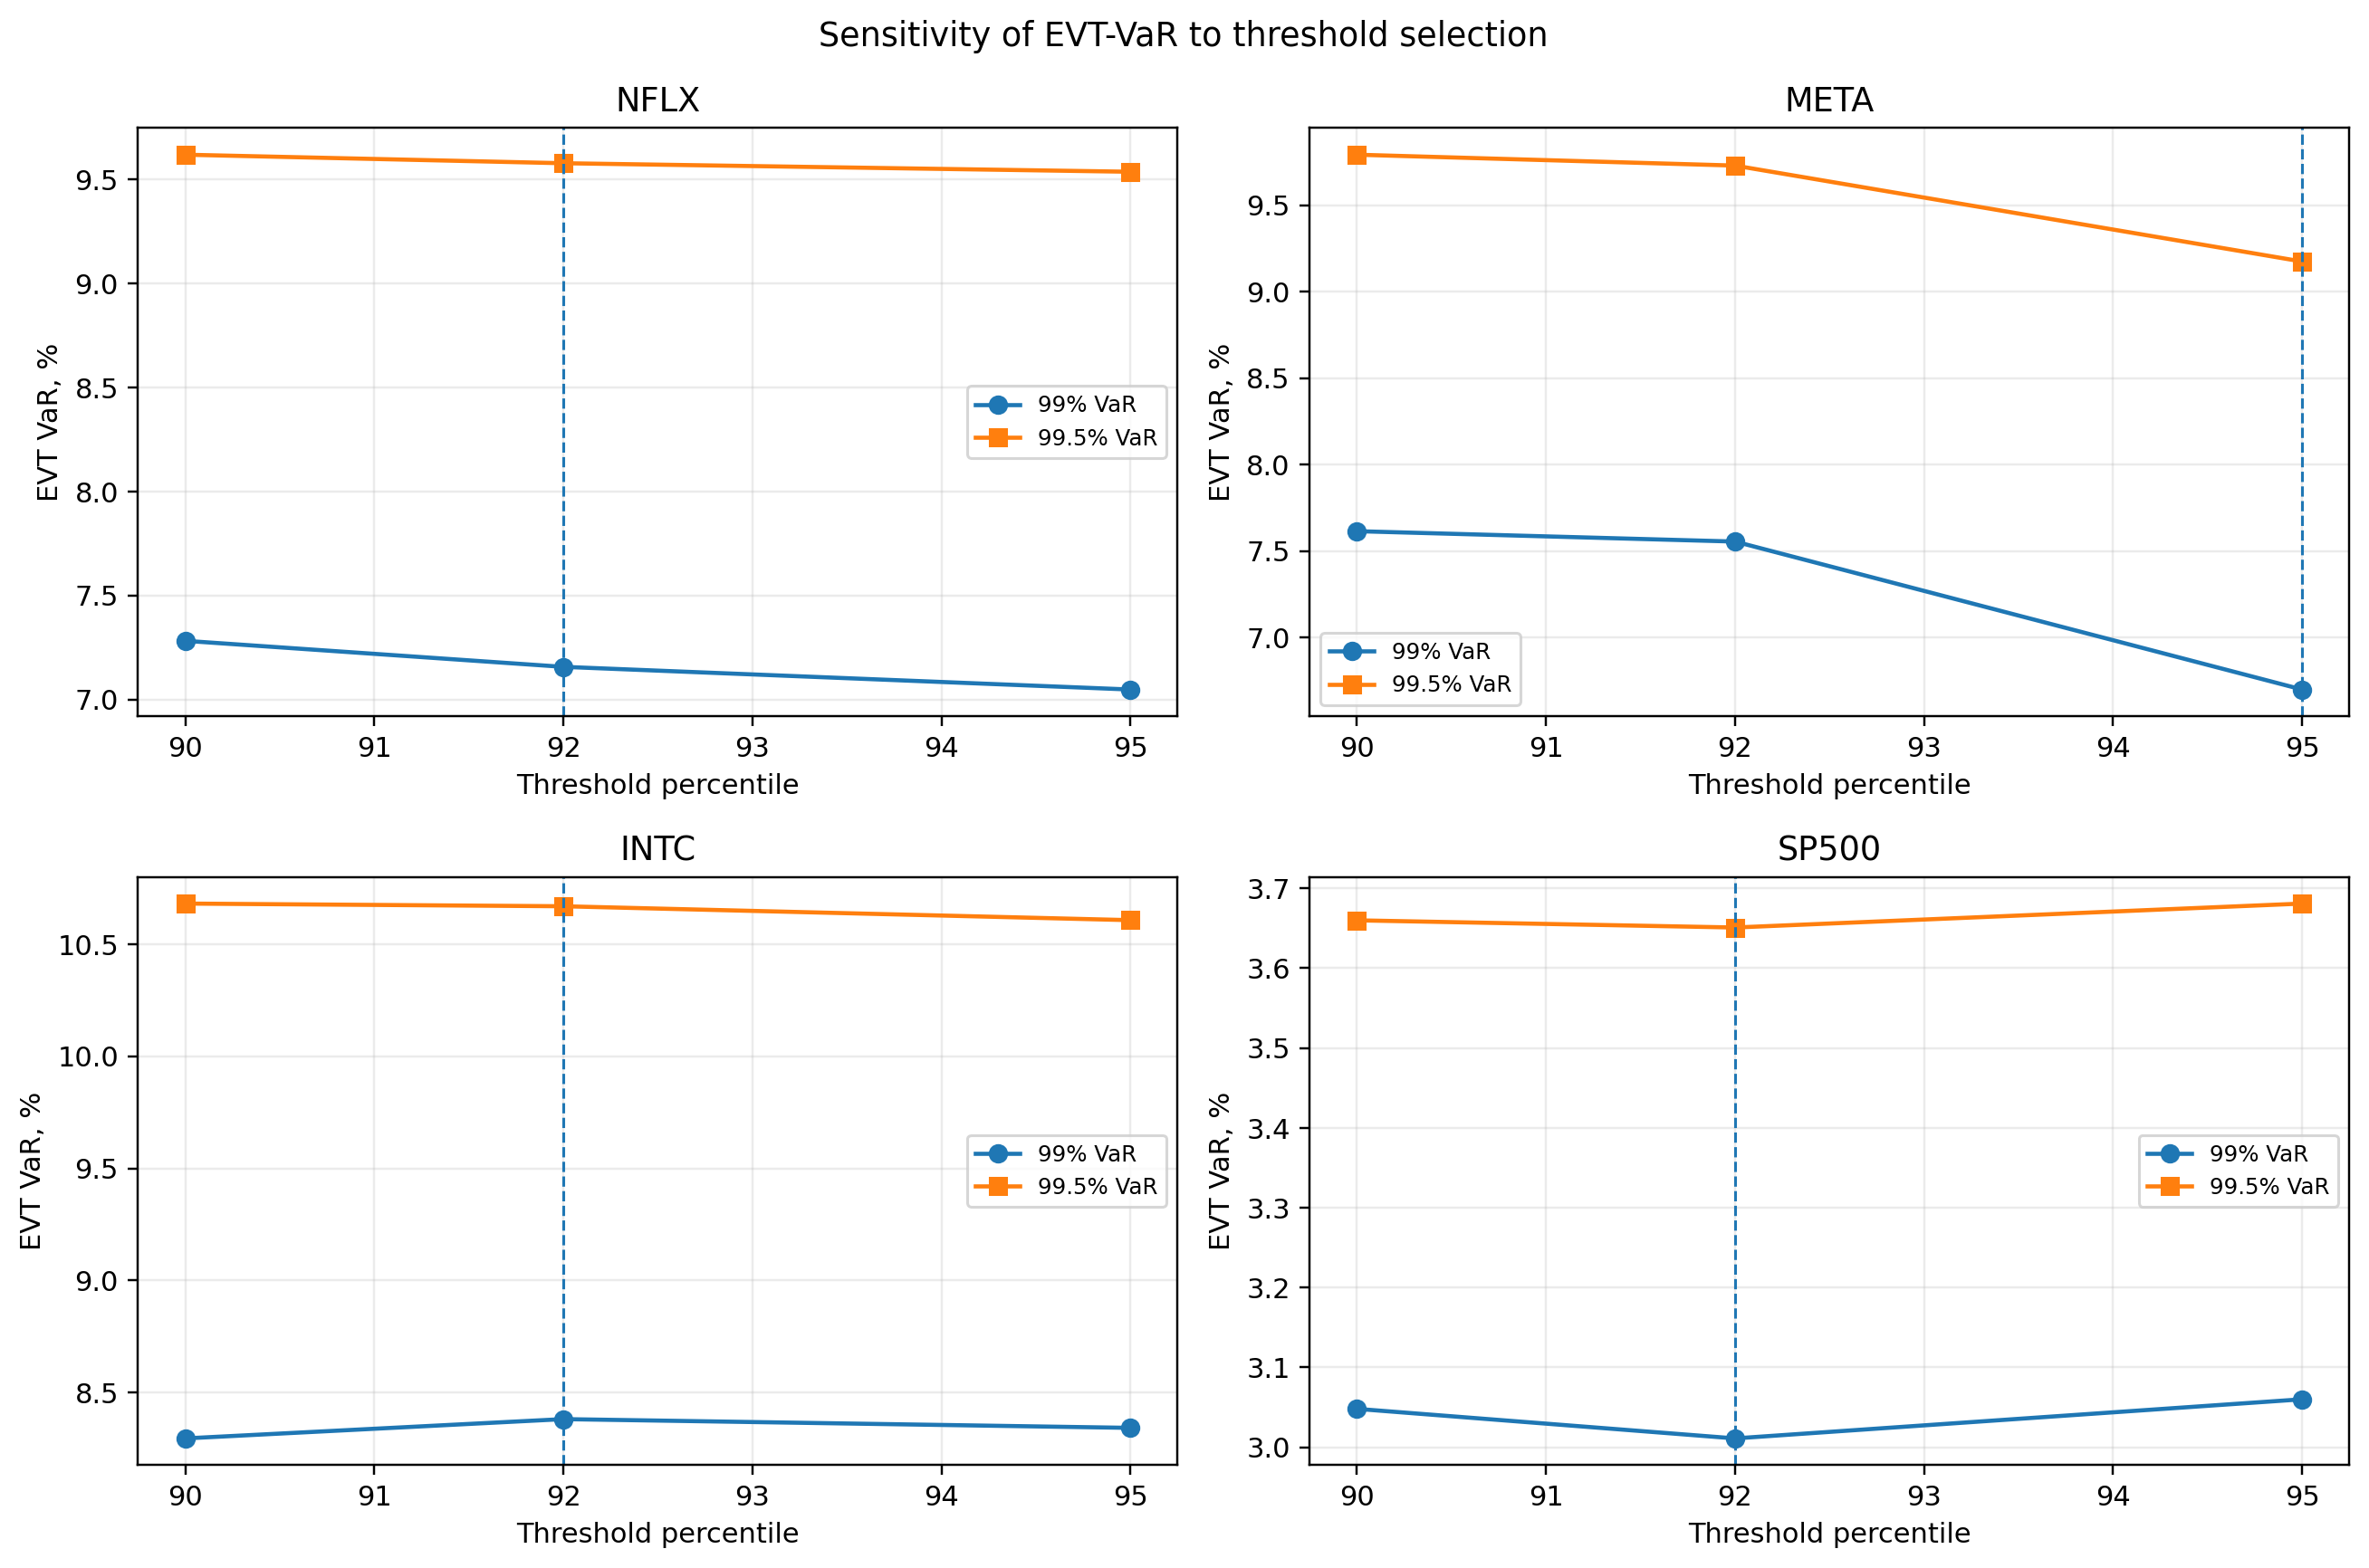

In [8]:
sensitivity = pd.read_csv(TABLE_DIR / "threshold_sensitivity.csv")
display(sensitivity.style.format({
    "threshold_quantile":"{:.0%}","threshold":"{:.2%}","xi":"{:.3f}","beta":"{:.4f}",
    "cvm_bootstrap_p":"{:.3f}","confidence":"{:.1%}","evt_var":"{:.2%}","evt_es":"{:.2%}"
}))
display(Image(filename=str(FIG_DIR / "07_var_threshold_sensitivity.png"), width=900))

## 8. Conclusions

1. All four loss series have positive fitted GPD shape parameters, but individual equities have materially heavier tails than the S&P 500.
2. META has the largest shape estimate and the greatest ES uncertainty; a high threshold is essential for adequate fit.
3. EVT is most informative through ES and tail extrapolation rather than through a mechanically larger VaR in every case.
4. Rolling unconditional coverage is adequate for all eight model/level combinations.
5. Seven of eight conditional-coverage tests are passed. The 99.5% S&P 500 model fails because its violations are temporally clustered, showing that a static iid-GPD tail does not fully capture volatility dynamics.
6. A natural extension is a filtered EVT model in which GARCH-standardised residuals are modelled by POT.